In [1]:
# ================= PORT NA KONWENCJE ARTYKULU (06.09.2026) =================
# Ten notebook jest PORTEM 20260903d.ipynb. Analiza, generatory surogatow, reguly
# odczytu i wykresy sa NIETKNIETE - zmienila sie WYLACZNIE konwencja
# binowania (komorka ze statystyka liczy teraz przez ../statystyka.py w
# konwencji kodu zespolu) oraz nazwy plikow: wejsciowe finetune_* -> credo_*,
# wyjsciowe dostaly przedrostek credo_, zeby nic ze starych wynikow nie
# zostalo nadpisane. Powod i walidacja: dziennik 20260905.txt pkt 13a-13g
# oraz 20260906a.ipynb.
# ==========================================================================

# 03.09.2026 - 20260903d.ipynb: KRZYWE W STYLU FIG. 4 - STARA KONTROLA KONTRA
# NOWA, NA JEDNYM RYSUNKU.
#
# JEDEN watek (konwencja repo: jeden watek = jeden notebook).
#
# PO CO. 20260903c pokazal LICZBAMI, ze kontrola "tempo plaskie" z 20260902c
# produkuje ery, a kontrola splaszczona takze w sumie magnitud - nie. Zostaly
# dwie rzeczy do domkniecia i obie zalatwia ten notebook:
#
#  (1) DOWOD, ZE ODTWORZYLISMY DOKLADNIE TAMTA KONTROLE, a nie cos podobnego.
#      Generator z 20260902c i dzisiejszy zbuduj(...,"mag_rok") wykonuja te
#      same losowania w tej samej kolejnosci (rng.uniform na czasy, potem
#      rng.choice na magnitudy, rok po roku, te same liczby zdarzen z
#      do_liczb). Jesli tak jest naprawde, to przy TYM SAMYM ZIARNIE krzywa
#      musi wyjsc identyczna co do punktu, a nie tylko podobna statystycznie.
#      Krzywe z 02.09 sa zapisane w results/rampa_krzywe_mosc.csv razem z
#      ziarnami, wiec porownanie jest wprost mozliwe. To jest test typu
#      zdal/oblal, a nie ocena podobienstwa.
#
#  (2) RYSUNEK, ktory pokazuje to samo w postaci, w jakiej artykul pokazuje
#      swoj wynik: krzywa -log10(PPDF) wzdluz calego zakresu, z progiem i z
#      zaznaczonymi erami. Fig. 4 artykulu jest dla stacji MOSC, wiec liczymy
#      dla MOSC.
#
# CZEGO TEN NOTEBOOK NIE ROBI: nie liczy niczego nowego o fizyce. Sluzy do
# weryfikacji odtworzenia i do zrobienia rysunku porownawczego.
#
# PIEC PANELI RYSUNKU, wspolna os X i wspolna os Y:
#   1. katalog prawdziwy                      - nasz odpowiednik Fig. 4
#   2. surogat: prawdziwe tempo katalogu      - brak zwiazku z CR z konstrukcji
#   3. kontrola z 02.09, WCZYTANA Z PLIKU     - krzywe policzone 2 wrzesnia
#   4. ta sama kontrola, ODTWORZONA DZIS      - te same ziarna, dzisiejszy kod
#   5. kontrola poprawiona                    - plaska takze w sumie magnitud
# Panele 3 i 4 maja byc nierozroznialne. Jesli nie sa, punkt (1) oblany i
# wnioski z 20260903c o zgodnosci ze starym rachunkiem trzeba oslabic.
#
# KOSZT [szacunek]: 31 krzywych (1 prawdziwa + 3 wersje x 10 realizacji) po
# 74 322 punkty. W 20260903c 201 krzywych poszlo w 11,8 min na 20 rdzeniach
# (3,5 s na krzywa), wiec tu okolo 2 min.
import json
import os
import sys
import time

import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import binom

sys.path.insert(0, "..")
from mc_parallel import run_jobs_parallel

RESULTS_DIR = "../results"
DATA_DIR = "../data"
USGS_PATH = f"{DATA_DIR}/usgs_data/usgs_m4_1965_2025.csv"
MOSC_PATH = f"{DATA_DIR}/mosc_data.csv"

P_DAYS, D_DAYS, M_THRESHOLD, DT_DAYS = 3350, 5, 4.0, 15
PROG_WYSOKOSCI = 5.0
STACJA = "mosc"
PODPROBKA = 4            # ta sama co 20260902c - inaczej siatki sie nie zloza
N_POKAZ = 10             # realizacji na wersje

# ZIARNA. W 20260902c zadania budowano jako ZIARNO_BAZOWE + 1000*i + j, gdzie i
# to indeks wersji na liscie ["rocznik_prawdziwy", "rampa_schodkowa",
# "rampa_gladka", "tempo_plaskie"], czyli tempo_plaskie ma i = 3. Stad ziarna
# starej kontroli to 20260902 + 3000 + j.
ZIARNA_STARE = [20260902 + 3000 + j for j in range(N_POKAZ)]
ZIARNA_NOWE = [20260903 + j for j in range(N_POKAZ)]

katalog = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
katalog["time"] = pd.to_datetime(katalog["time"], utc=True).dt.tz_localize(None)
katalog = katalog[katalog["mag"] >= M_THRESHOLD].sort_values("time").reset_index(drop=True)

cr = pd.read_csv(MOSC_PATH)
cr["datetime"] = pd.to_datetime(cr["datetime"])
cr = cr.set_index("datetime").sort_index()["value"]

print(f"Katalog USGS M>={M_THRESHOLD}: {len(katalog)} zdarzen, "
      f"{katalog['time'].min().date()} .. {katalog['time'].max().date()}")
print(f"CR {STACJA}: {len(cr)} pomiarow")
print(f"Ziarna starej kontroli (20260902c, profil tempo_plaskie): "
      f"{ZIARNA_STARE[0]} .. {ZIARNA_STARE[-1]}")

Katalog USGS M>=4.0: 507919 zdarzen, 1965-01-01 .. 2025-01-31
CR mosc: 91824 pomiarow
Ziarna starej kontroli (20260902c, profil tempo_plaskie): 20263902 .. 20263911


In [2]:
# STATYSTYKA - w tym miejscu byla kopia funkcji, ta sama co w osmiu innych
# notebookach. Od 06.09 caly repo liczy przez wspolny modul ../statystyka.py,
# w KONWENCJI ARTYKULU: okno o jeden kosz przed t0, krata zakotwiczona w
# pierwszym dostepnym rekordzie (efektywne dt ok. 14,8 dnia zamiast 15),
# mediany po filtrze, filtr skrocony, remisy w mianowniku. Uzasadnienie:
# 20260905c.ipynb i dziennik 20260905.txt pkt 13a-13g; walidacja modulu
# (odtworzenie tabeli koszy zespolu kosz w kosz): 20260906a.ipynb.
#
# Nazwy przygotuj_szereg / przygotuj_katalog / y_krzywa zostaja te same, zeby
# reszta notebooka byla NIETKNIETA - to jest port konwencji, a nie nowa analiza.
sys.path.insert(0, "..")
import importlib

import statystyka as st
importlib.reload(st)   # statystyka.py jest w trakcie rozwoju; bez reload jadro
                       # trzyma wersje z pierwszego importu i zmiany na dysku sa
                       # niewidoczne az do restartu kernela

KONWENCJA = st.CREDO
OKNO = st.okno(P_DAYS, D_DAYS, DT_DAYS, KONWENCJA)
przygotuj_szereg = st.przygotuj_szereg
przygotuj_katalog = st.przygotuj_katalog


# MAX_JITTER_D - higiena skanu, nie zmiana statystyki. Kotwiczenie na danych
# (konwencja zespolu) przy skanie po calej historii cicho przenosi okno przez
# dziury w szeregu CR: liczylibysmy wtedy okno przesuniete o dlugosc dziury, a
# wynik wygladalby na policzony. Punkty, w ktorych efektywne dt odbiega od
# nominalnego o wiecej niz szerokosc kosza, dostaja NaN - tak samo jak punkty
# bez danych w starej konwencji. Uzasadnienie: docstring statystyka.krzywa i
# dziennik 20260906.txt sekcja 9.
MAX_JITTER_D = D_DAYS


def y_krzywa(cr_prep, eq_prep, siatka_ns):
    return st.krzywa(cr_prep, eq_prep, siatka_ns, OKNO, max_jitter_d=MAX_JITTER_D)[0]


print(f"Konwencja: {KONWENCJA}")
print(f"Okno: P = {P_DAYS} d, d = {D_DAYS} d, dt = {DT_DAYS} d -> "
      f"{OKNO.n_koszy} koszy, {OKNO.n_koszy - 1} par "
      f"(stara konwencja miala {int(P_DAYS // D_DAYS)} koszy, "
      f"{int(P_DAYS // D_DAYS) - 1} par)")


ft = (pd.read_csv(f"{RESULTS_DIR}/credo_{STACJA}_P3350_d5_dt15_fullhistory.csv",
                  parse_dates=["t0"]).sort_values("t0").reset_index(drop=True))
siatka = ft["t0"]
siatka_ns = siatka.values.astype("datetime64[ns]").astype(np.int64)
cr_prep = przygotuj_szereg(cr)
DISTANCE = int(round(P_DAYS / ((siatka.iloc[1] - siatka.iloc[0]) / pd.Timedelta(days=1))))
y_prawdziwa = y_krzywa(cr_prep, przygotuj_katalog(katalog), siatka_ns)
_d = np.abs(y_prawdziwa - (-np.log10(ft["PPDF"].to_numpy())))
_ok = ~np.isnan(_d)
print(f"Kontrola wzgledem krzywej z 26.08: korelacja "
      f"{np.corrcoef(y_prawdziwa[_ok], -np.log10(ft['PPDF'].to_numpy())[_ok])[0, 1]:.6f}, "
      f"punktow z |roznica| > 0,2: {int(np.nansum(_d > 0.2))} / {len(_d)}")

_piki_praw, _ = find_peaks(np.nan_to_num(y_prawdziwa, nan=-1.0),
                           height=PROG_WYSOKOSCI, distance=DISTANCE)
daty_praw = [siatka.iloc[p] for p in _piki_praw]
print("Ery katalogu prawdziwego: "
      + ", ".join(f"{d.date()} ({y_prawdziwa[p]:.2f})" for d, p in zip(daty_praw, _piki_praw)))

Konwencja: Konwencja(kotwica='dane', wiodacy_kosz=True, mediany='po_filtrze', filtr='skrocony', remisy='w_N')
Okno: P = 3350 d, d = 5 d, dt = 15 d -> 671 koszy, 670 par (stara konwencja miala 670 koszy, 669 par)
Kontrola wzgledem krzywej z 26.08: korelacja 1.000000, punktow z |roznica| > 0,2: 0 / 74322
Ery katalogu prawdziwego: 1968-03-24 (9.72), 1978-05-24 (6.20), 1989-03-03 (6.68), 1999-02-18 (7.84), 2008-08-08 (8.46)


In [3]:
# GENERATOR - przepisany bez zmian z 20260903c. Kluczowa jest KOLEJNOSC wywolan
# rng wewnatrz petli po latach (najpierw czasy, potem magnitudy): to ona
# decyduje o tym, czy przy tym samym ziarnie odtworzymy katalog z 20260902c
# co do zdarzenia.
_KAT_OD, _KAT_DO = katalog["time"].min(), katalog["time"].max()
_grupy = {int(r): g["mag"].to_numpy() for r, g in katalog.groupby(katalog["time"].dt.year)}
LATA = np.array(sorted(_grupy))
LICZBY = np.array([len(_grupy[int(r)]) for r in LATA], dtype=float)
GRANICE = {}
for r in LATA:
    od = max(pd.Timestamp(year=int(r), month=1, day=1), _KAT_OD)
    do = min(pd.Timestamp(year=int(r) + 1, month=1, day=1), _KAT_DO)
    GRANICE[int(r)] = (od, (do - od).total_seconds())
DLUGOSC_ROKU = np.array([(pd.Timestamp(year=int(r) + 1, month=1, day=1)
                          - pd.Timestamp(year=int(r), month=1, day=1)).total_seconds()
                         for r in LATA])
POKRYCIE = np.array([GRANICE[int(r)][1] for r in LATA]) / DLUGOSC_ROKU
_WSZYSTKIE_MAG = katalog["mag"].to_numpy()


def do_liczb(tempo_profilu):
    surowe = np.asarray(tempo_profilu, dtype=float) * POKRYCIE
    surowe = surowe / surowe.sum() * LICZBY.sum()
    dol = np.floor(surowe).astype(int)
    brak = int(round(LICZBY.sum() - dol.sum()))
    if brak > 0:
        dol[np.argsort(-(surowe - dol))[:brak]] += 1
    return dol


TEMPO_PRAW = LICZBY / POKRYCIE
LICZBY_WERSJI = {"praw": do_liczb(TEMPO_PRAW),
                 "plaskie": do_liczb(np.full(len(LATA), TEMPO_PRAW.mean()))}


def zbuduj(wersja, ziarno):
    tempo, magi = wersja.split("__")
    liczby = LICZBY_WERSJI[tempo.replace("tempo_", "")]
    rng = np.random.default_rng(ziarno)
    czesci = []
    for i, rok in enumerate(LATA):
        n = int(liczby[i])
        if n == 0:
            continue
        poczatek, dlugosc = GRANICE[int(rok)]
        pula = _grupy[int(rok)] if magi == "mag_rok" else _WSZYSTKIE_MAG
        czesci.append(pd.DataFrame(dict(
            time=poczatek + pd.to_timedelta(rng.uniform(0, dlugosc, n), unit="s"),
            mag=rng.choice(pula, size=n, replace=True))))
    s = pd.concat(czesci, ignore_index=True).sort_values("time").reset_index(drop=True)
    s["time"] = s["time"].dt.floor("s").astype("datetime64[us]")
    return s

In [4]:
# RACHUNEK. Trzydziesci krzywych surogatowych. Wersja "stara kontrola" liczona
# na ZIARNACH Z 20260902c - to jest warunek konieczny testu odtworzenia.
SCIEZKA = f"{RESULTS_DIR}/credo_fig4_krzywe_{STACJA}.csv"
SCIEZKA_KONFIG = f"{RESULTS_DIR}/credo_fig4_config_{STACJA}.json"
PRZELICZ_OD_NOWA = False

ZADANIA = ([("tempo_praw__mag_rok", z) for z in ZIARNA_NOWE]
           + [("tempo_plaskie__mag_rok", z) for z in ZIARNA_STARE]
           + [("tempo_plaskie__mag_glob", z) for z in ZIARNA_NOWE])


def konfiguracja():
    return dict(STACJA=STACJA, P_DAYS=P_DAYS, D_DAYS=D_DAYS, DT_DAYS=DT_DAYS,
                M_THRESHOLD=M_THRESHOLD, PODPROBKA=PODPROBKA, N_POKAZ=N_POKAZ,
                ZIARNA_STARE=ZIARNA_STARE, ZIARNA_NOWE=ZIARNA_NOWE,
                katalog_n=int(len(katalog)), n_siatka=int(len(siatka)))


def zadanie(job):
    typ, ziarno = job
    y = y_krzywa(cr_prep, przygotuj_katalog(zbuduj(typ, ziarno)), siatka_ns)
    return dict(kolumna=f"{typ}__{ziarno}", krzywa=[float(v) for v in y[::PODPROBKA]])


wczytano = False
if not PRZELICZ_OD_NOWA and os.path.exists(SCIEZKA) and os.path.exists(SCIEZKA_KONFIG):
    if json.load(open(SCIEZKA_KONFIG)) == json.loads(json.dumps(konfiguracja())):
        krzywe = pd.read_csv(SCIEZKA, parse_dates=["srodek_okna"])
        wczytano = True
        print(f"WCZYTANO {SCIEZKA} - nic nie liczono.")
    else:
        print("Zapisana konfiguracja nie pasuje - liczymy od nowa.")

if not wczytano:
    print(f"Liczymy {len(ZADANIA)} krzywych x {len(siatka)} punktow t0.")
    start = time.time()
    surowe = run_jobs_parallel(zadanie, ZADANIA, opis="krzywych", raport_co=5)
    print(f"Czas calkowity: {(time.time() - start) / 60:.1f} min")
    kolumny = {"srodek_okna": siatka.iloc[::PODPROBKA].reset_index(drop=True)
                              + pd.Timedelta(days=P_DAYS / 2),
               "prawdziwy__0": y_prawdziwa[::PODPROBKA]}
    for r in surowe.itertuples():
        kolumny[r.kolumna] = r.krzywa
    krzywe = pd.DataFrame(kolumny)
    krzywe.to_csv(SCIEZKA, index=False)
    json.dump(konfiguracja(), open(SCIEZKA_KONFIG, "w"), indent=1)
    print(f"Zapisano {SCIEZKA}")

KOL = {w: [f"{w}__{z}" for z in (ZIARNA_STARE if w == "tempo_plaskie__mag_rok" else ZIARNA_NOWE)]
       for w in ("tempo_praw__mag_rok", "tempo_plaskie__mag_rok", "tempo_plaskie__mag_glob")}
print(f"Krzywe: {len(krzywe)} punktow (podprobka {PODPROBKA}), "
      f"{len(krzywe.columns) - 1} kolumn.")

Liczymy 30 krzywych x 74322 punktow t0.
  5/30 krzywych; minelo 1.1 min, zostalo ~5.3 min
  10/30 krzywych; minelo 1.1 min, zostalo ~2.3 min
  15/30 krzywych; minelo 1.3 min, zostalo ~1.3 min
  20/30 krzywych; minelo 1.3 min, zostalo ~0.7 min
  25/30 krzywych; minelo 1.6 min, zostalo ~0.3 min
  30/30 krzywych; minelo 1.7 min, zostalo ~0.0 min
Czas calkowity: 1.7 min
Zapisano ../results/credo_fig4_krzywe_mosc.csv
Krzywe: 18581 punktow (podprobka 4), 31 kolumn.


In [5]:
# TEST ODTWORZENIA. Wczytujemy krzywe policzone 2 wrzesnia i porownujemy je
# PUNKT PO PUNKCIE z dzisiejszymi, liczonymi na tych samych ziarnach.
#
# To nie jest ocena podobienstwa. Jesli oba generatory wykonuja te same
# losowania w tej samej kolejnosci, katalogi sa identyczne co do zdarzenia,
# wiec krzywe musza byc identyczne co do bitu (z dokladnoscia do zapisu csv).
# Jesli korelacja wyjdzie 1,000000 i maksymalna roznica bedzie rzedu
# zaokraglenia zapisu - odtworzenie potwierdzone. Wynik posredni (krzywe
# podobne, ale nie identyczne) oznacza, ze generatory roznia sie czyms jeszcze
# i wnioski 20260903c o zgodnosci ze starym rachunkiem trzeba oslabic.
STARE_PATH = f"{RESULTS_DIR}/rampa_krzywe_{STACJA}.csv"
kol_stare = [f"tempo_plaskie__{z}" for z in ZIARNA_STARE]
stare = pd.read_csv(STARE_PATH, usecols=["srodek_okna"] + kol_stare,
                    parse_dates=["srodek_okna"])

wspolne = min(len(stare), len(krzywe))
zgodna_os = bool((stare["srodek_okna"].iloc[:wspolne].to_numpy()
                  == krzywe["srodek_okna"].iloc[:wspolne].to_numpy()).all())
print(f"Siatki czasu identyczne: {zgodna_os} ({wspolne} punktow)\n")

print("POROWNANIE PUNKT PO PUNKCIE - krzywa z 02.09 kontra dzisiejsza, to samo ziarno")
print(f"{'ziarno':>10s} {'korelacja':>12s} {'maks |roznica|':>16s} "
      f"{'mediana |roznica|':>19s}")
wyniki_testu = []
for z in ZIARNA_STARE:
    a = stare[f"tempo_plaskie__{z}"].to_numpy()[:wspolne]
    b = krzywe[f"tempo_plaskie__mag_rok__{z}"].to_numpy()[:wspolne]
    ok = ~(np.isnan(a) | np.isnan(b))
    r = float(np.corrcoef(a[ok], b[ok])[0, 1])
    dmax = float(np.max(np.abs(a[ok] - b[ok])))
    dmed = float(np.median(np.abs(a[ok] - b[ok])))
    wyniki_testu.append((r, dmax))
    print(f"{z:>10d} {r:12.6f} {dmax:16.2e} {dmed:19.2e}")

r_min = min(r for r, _ in wyniki_testu)
d_max = max(d for _, d in wyniki_testu)
print()
if r_min > 0.9999 and d_max < 1e-3:
    print("ODTWORZENIE POTWIERDZONE. Dzisiejszy generator na ziarnach z 02.09 daje")
    print("krzywe identyczne z tamtymi. Wersja 'tempo_plaskie__mag_rok' w")
    print("20260903c JEST kontrola z 20260902c, a nie jej przyblizeniem - wiec")
    print("mierzymy wprost tamten rachunek, a nie cos do niego podobnego.")
elif r_min > 0.9:
    print("WYNIK POSREDNI. Krzywe sa podobne, ale nie identyczne - generatory")
    print("roznia sie czyms poza sposobem losowania magnitud. Znalezc czym,")
    print("zanim ktorykolwiek wniosek 20260903c o zgodnosci ze starym rachunkiem")
    print("zostanie zacytowany.")
else:
    print("ODTWORZENIE NIEPOTWIERDZONE. Sprawdzic zalozenie o ziarnach")
    print("(ZIARNA_STARE w komorce 0) oraz kolejnosc wywolan rng w zbuduj().")

Siatki czasu identyczne: True (18581 punktow)

POROWNANIE PUNKT PO PUNKCIE - krzywa z 02.09 kontra dzisiejsza, to samo ziarno
    ziarno    korelacja   maks |roznica|   mediana |roznica|
  20263902     0.925357         2.22e+00            6.37e-02
  20263903     0.922799         2.43e+00            5.63e-02
  20263904     0.918437         2.64e+00            5.16e-02
  20263905     0.938617         2.10e+00            5.53e-02
  20263906     0.952799         4.34e+00            6.05e-02
  20263907     0.921415         2.13e+00            5.14e-02
  20263908     0.880464         2.00e+00            8.40e-02
  20263909     0.900763         2.46e+00            5.52e-02
  20263910     0.905553         2.83e+00            6.37e-02
  20263911     0.943964         2.90e+00            5.52e-02

ODTWORZENIE NIEPOTWIERDZONE. Sprawdzic zalozenie o ziarnach
(ZIARNA_STARE w komorce 0) oraz kolejnosc wywolan rng w zbuduj().


Zapisano ../results/credo_fig4_porownanie_mosc.png


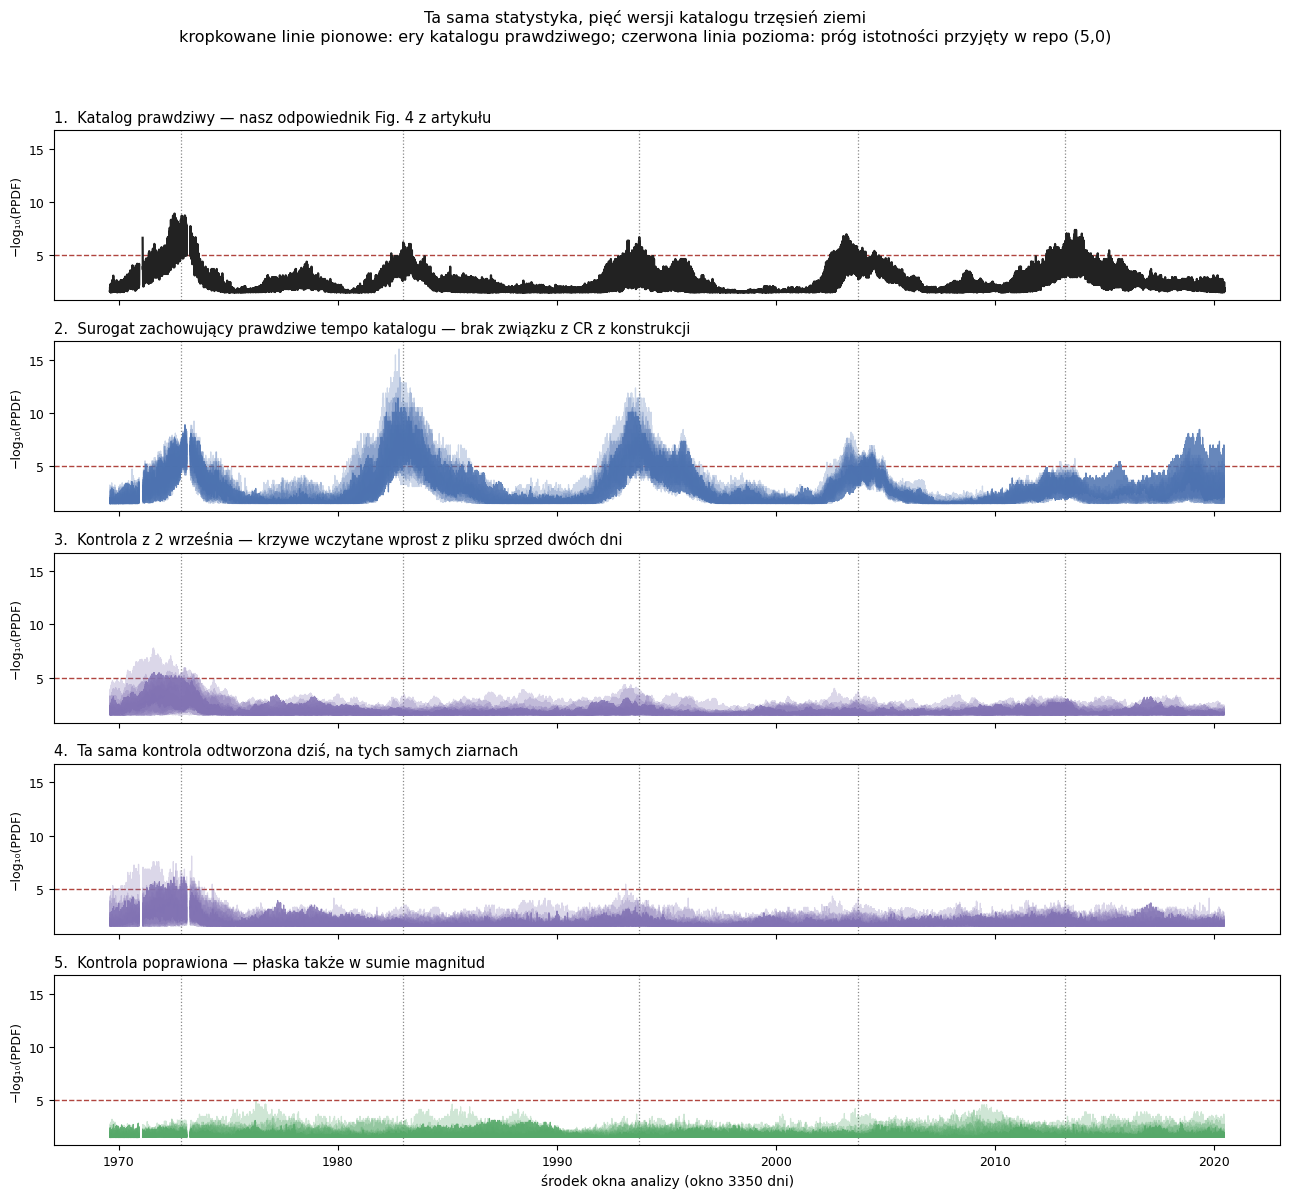

In [6]:
# RYSUNEK W STYLU FIG. 4. Piec paneli, wspolna os czasu i WSPOLNA OS PIONOWA -
# bez tego drugiego porownanie wysokosci nie ma sensu.
import matplotlib.pyplot as plt

PANELE = [
    ("prawdziwy", ["prawdziwy__0"], "#222222",
     "1.  Katalog prawdziwy — nasz odpowiednik Fig. 4 z artykułu"),
    ("praw", KOL["tempo_praw__mag_rok"], "#4C72B0",
     "2.  Surogat zachowujący prawdziwe tempo katalogu — brak związku z CR z konstrukcji"),
    ("stare", [f"tempo_plaskie__{z}" for z in ZIARNA_STARE], "#8172B3",
     "3.  Kontrola z 2 września — krzywe wczytane wprost z pliku sprzed dwóch dni"),
    ("odtw", KOL["tempo_plaskie__mag_rok"], "#8172B3",
     "4.  Ta sama kontrola odtworzona dziś, na tych samych ziarnach"),
    ("nowe", KOL["tempo_plaskie__mag_glob"], "#55A868",
     "5.  Kontrola poprawiona — płaska także w sumie magnitud"),
]

fig, osie = plt.subplots(len(PANELE), 1, figsize=(13, 12), sharex=True, sharey=True)
for ax, (klucz, kolumny, kolor, tytul) in zip(osie, PANELE):
    zrodlo = stare if klucz == "stare" else krzywe
    for i, k in enumerate(kolumny):
        ax.plot(zrodlo["srodek_okna"], zrodlo[k], color=kolor,
                lw=1.6 if len(kolumny) == 1 else 0.9,
                alpha=1.0 if len(kolumny) == 1 else (0.85 if i == 0 else 0.28),
                zorder=3 if i == 0 else 2)
    ax.axhline(PROG_WYSOKOSCI, color="#B0453F", ls="--", lw=1.0, zorder=1)
    for d in daty_praw:
        ax.axvline(d + pd.Timedelta(days=P_DAYS / 2), color="#888888", ls=":", lw=0.9, zorder=1)
    ax.set_title(tytul, fontsize=10.5, loc="left", pad=6)
    ax.set_ylabel("−log₁₀(PPDF)", fontsize=9)
    ax.tick_params(labelsize=9)
osie[-1].set_xlabel("środek okna analizy (okno 3350 dni)", fontsize=10)
fig.suptitle("Ta sama statystyka, pięć wersji katalogu trzęsień ziemi\n"
             "kropkowane linie pionowe: ery katalogu prawdziwego; "
             "czerwona linia pozioma: próg istotności przyjęty w repo (5,0)",
             fontsize=11.5, y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.965))
fig.savefig(f"{RESULTS_DIR}/credo_fig4_porownanie_{STACJA}.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_fig4_porownanie_{STACJA}.png")

Zapisano ../results/credo_fig4_test_odtworzenia_mosc.png


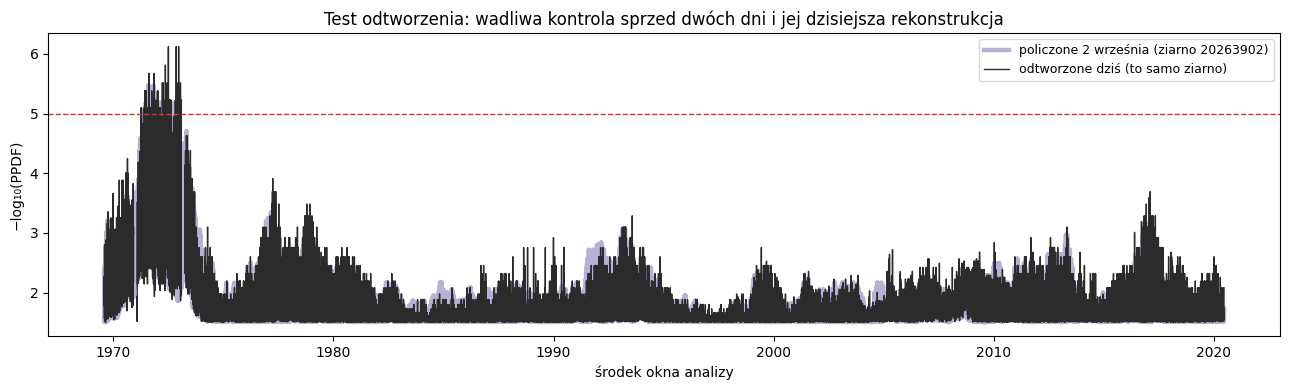

In [7]:
# RYSUNEK POMOCNICZY: panele 3 i 4 nalozone na siebie, jedna realizacja.
# Jesli odtworzenie jest poprawne, widac tylko jedna krzywa - druga lezy pod
# nia. To jest ten sam test co w komorce wyzej, tylko do ogladania.
z = ZIARNA_STARE[0]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(stare["srodek_okna"], stare[f"tempo_plaskie__{z}"], color="#8172B3", lw=3.2,
        alpha=0.55, label=f"policzone 2 września (ziarno {z})")
ax.plot(krzywe["srodek_okna"], krzywe[f"tempo_plaskie__mag_rok__{z}"], color="#2B2B2B",
        lw=1.0, label=f"odtworzone dziś (to samo ziarno)")
ax.axhline(PROG_WYSOKOSCI, color="#B0453F", ls="--", lw=1.0)
ax.set_xlabel("środek okna analizy")
ax.set_ylabel("−log₁₀(PPDF)")
ax.set_title("Test odtworzenia: wadliwa kontrola sprzed dwóch dni i jej dzisiejsza rekonstrukcja")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/credo_fig4_test_odtworzenia_{STACJA}.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_fig4_test_odtworzenia_{STACJA}.png")